# Phase 7: LLM-Based Highlight Selection (Stage A)

Predicts which sentences a parent would highlight using Claude with extended thinking.
Three conditions compared in separate batches:
1. **zero_shot** — no examples
2. **global** — N_GLOBAL examples from other parents
3. **per_parent** — all of this parent's highlights from their other scenarios

Evaluation: leave-one-scenario-out within each parent. Primary question: does knowing a
parent's own highlight history beat a global pool of examples from other parents?

In [45]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'anthropic', 'python-dotenv', 'scikit-learn'], check=False)
print('Dependencies ready.')

Dependencies ready.


In [46]:
import os, json, pickle, glob, time, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

from dotenv import load_dotenv
import anthropic

_nb_dir = os.path.abspath('.')
load_dotenv(os.path.join(_nb_dir, '..', '..', '.env'))
client = anthropic.Anthropic(api_key=os.environ['CLAUDE_API_KEY'])
MODEL = 'claude-sonnet-4-6'
SEED = 20260506
np.random.seed(SEED)

TRACES_DIR = os.path.join(_nb_dir, '..', 'traces')
CACHE_PATH = os.path.join(TRACES_DIR, 'llm_selection_cache.json')

# ── Load pickled data ──────────────────────────────────────────────────────
with open(os.path.join(TRACES_DIR, 'panel_meta.pkl'), 'rb') as f:
    panel_meta = pickle.load(f)
with open(os.path.join(TRACES_DIR, 'span_universe_df.pkl'), 'rb') as f:
    span_universe_df = pickle.load(f)
with open(os.path.join(TRACES_DIR, 'df_sel_dedup.pkl'), 'rb') as f:
    df_sel_dedup = pickle.load(f)

# ── Load moderation sessions (scenario_prompt + original_response) ─────────
_exports = sorted(glob.glob(os.path.join(
    _nb_dir, '..', '..', '..', 'data-exports', '*', 'moderation_sessions_export_*.csv')))
DATA_DIR = os.path.dirname(_exports[-1])
EXPORT_TS = os.path.basename(_exports[-1]).split('_export_')[1].replace('.csv', '')

mod_df = pd.read_csv(os.path.join(DATA_DIR, f'moderation_sessions_export_{EXPORT_TS}.csv'))
mod_df['is_final_version'] = mod_df['is_final_version'].astype(str).str.strip().str.lower()
mod_df = mod_df[mod_df['is_final_version'].isin(['true', '1'])].copy()
mod_df = mod_df[mod_df['user_id'].isin(set(df_sel_dedup['parent_id']))].copy()

print(f'panel_meta:       {panel_meta.shape}  positive rate: {panel_meta["y"].mean():.1%}')
print(f'span_universe_df: {span_universe_df.shape}')
print(f'df_sel_dedup:     {df_sel_dedup.shape}')
print(f'mod_df (final):   {mod_df.shape}')

panel_meta:       (1612, 31)  positive rate: 10.4%
span_universe_df: (836, 9)
df_sel_dedup:     (200, 48)
mod_df (final):   (83, 38)


## 7.1  Build scenario text lookup

In [47]:
scenario_text = {}
for sid in span_universe_df['scenario_id'].unique():
    spans = (span_universe_df[span_universe_df['scenario_id'] == sid]
             .sort_values('sent_idx'))
    mod_rows = mod_df[mod_df['scenario_id'] == sid]
    if mod_rows.empty:
        continue
    mod_row = mod_rows.iloc[0]
    scenario_text[sid] = {
        'prompt':    mod_row['scenario_prompt'],
        'sentences': list(zip(spans['sent_idx'].tolist(), spans['text'].tolist())),
    }

print(f'Scenarios with text: {len(scenario_text)}')
# Sanity: show one example
sid_ex = list(scenario_text.keys())[0]
print(f'\nExample scenario {sid_ex}:')
print(f'  Prompt: {str(scenario_text[sid_ex]["prompt"])[:80]}...')
print(f'  Sentences: {len(scenario_text[sid_ex]["sentences"])}')

Scenarios with text: 45

Example scenario scenario_b4a47314-1b67-48c7-b860-ca9770163d29:
  Prompt: Should I tell my friends I’m nonbinary like for real, or just let them keep call...
  Sentences: 37


## 7.2  Build example banks

In [48]:
N_GLOBAL = 6   # examples from other parents for the global condition

# Per-parent bank: highlights sorted by scenario_id for deterministic ordering
parent_examples = {}
for pid, grp in df_sel_dedup.groupby('parent_id'):
    entries = []
    for _, row in grp.sort_values('scenario_id').iterrows():
        sid = row['scenario_id']
        if sid not in scenario_text:
            continue
        entries.append({
            'scenario_id':    sid,
            'highlight_text': str(row['highlight_text']),
            'rationale_text': str(row.get('rationale_text', '')) if pd.notna(row.get('rationale_text')) else '',
            'scenario_prompt': str(scenario_text[sid]['prompt']),
        })
    parent_examples[pid] = entries

# Global bank: all examples across all parents
global_examples = [
    {**ex, 'parent_id': pid}
    for pid, exs in parent_examples.items()
    for ex in exs
]

print(f'Global pool: {len(global_examples)} examples')
for pid, exs in sorted(parent_examples.items()):
    n_scen = len(set(e['scenario_id'] for e in exs))
    print(f'  Parent {pid}: {len(exs):3d} highlights across {n_scen} scenarios')

Global pool: 200 examples
  Parent 01842943-df97-48af-b7c2-577ca2d3dff7:  12 highlights across 4 scenarios
  Parent 08067f0e-43a9-4578-9302-aec81b38dfb3:  14 highlights across 4 scenarios
  Parent 0cc5f7a1-0d10-4058-b143-89359442904b:  19 highlights across 4 scenarios
  Parent 1bda9733-3ffb-41fa-ba7b-228820abe61c:   4 highlights across 3 scenarios
  Parent 3668ceba-1856-42d1-baed-5d35f9dfd4f0:   7 highlights across 4 scenarios
  Parent 53b10974-dcb5-4ed8-886e-d2fa2719802e:   7 highlights across 4 scenarios
  Parent 620f9606-c49d-4fa2-8c58-132d5f0d8477:   5 highlights across 4 scenarios
  Parent 6254e891-6c80-4d57-b62c-ab7be3460d0b:   5 highlights across 4 scenarios
  Parent 9945a7e3-1a9b-4940-89cf-3e2571a0dcf5:   4 highlights across 4 scenarios
  Parent aae34961-d3ea-4772-a027-5ebf40ababf1:   4 highlights across 2 scenarios
  Parent bb385a79-a474-40cb-abd9-59c7bd5fdc39:   6 highlights across 4 scenarios
  Parent bd2d81fb-d3d8-40b1-a6f7-93818b8c4867:  12 highlights across 4 scenarios
  

# ── Distribution of highlights per scenario ────────────────────────────────
highlights_per_scenario = (
    panel_meta.groupby(['parent_id', 'scenario_id'])['y']
    .sum()
    .reset_index(name='n_highlighted')
)
n_sents_per_scenario = (
    panel_meta.groupby(['parent_id', 'scenario_id'])['y']
    .count()
    .reset_index(name='n_sentences')
)
dist_df = highlights_per_scenario.merge(n_sents_per_scenario, on=['parent_id', 'scenario_id'])
dist_df['pct_highlighted'] = dist_df['n_highlighted'] / dist_df['n_sentences']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Count distribution
ax = axes[0]
counts = dist_df['n_highlighted'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', alpha=0.8)
ax.axvline(dist_df['n_highlighted'].mean(), color='tomato', linestyle='--',
           label=f'Mean = {dist_df["n_highlighted"].mean():.1f}')
ax.set_xlabel('Sentences highlighted per scenario')
ax.set_ylabel('(parent, scenario) pairs')
ax.set_title('Highlight count distribution')
ax.legend()

# % highlighted per scenario
ax2 = axes[1]
ax2.hist(dist_df['pct_highlighted'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax2.axvline(dist_df['pct_highlighted'].mean(), color='tomato', linestyle='--',
            label=f'Mean = {dist_df["pct_highlighted"].mean():.1%}')
ax2.set_xlabel('Fraction of sentences highlighted')
ax2.set_ylabel('(parent, scenario) pairs')
ax2.set_title('Highlight rate per scenario')
ax2.legend()

# Per-parent boxplot
ax3 = axes[2]
parent_order = (dist_df.groupby('parent_id')['n_highlighted']
                .mean().sort_values(ascending=False).index)
data_by_parent = [dist_df[dist_df['parent_id'] == pid]['n_highlighted'].values
                  for pid in parent_order]
ax3.boxplot(data_by_parent, vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
ax3.set_xticks(range(1, len(parent_order) + 1))
ax3.set_xticklabels([p[:8] for p in parent_order], rotation=45, ha='right', fontsize=7)
ax3.set_xlabel('Parent (truncated ID)')
ax3.set_ylabel('Highlights per scenario')
ax3.set_title('Per-parent highlight count\n(sorted by mean)')

plt.tight_layout()
plt.show()

print(f'(parent, scenario) pairs total:  {len(dist_df)}')
print(f'Pairs with 0 highlights:         {(dist_df["n_highlighted"] == 0).sum()}')
print(f'Mean highlights per scenario:    {dist_df["n_highlighted"].mean():.2f}')
print(f'Median:                          {dist_df["n_highlighted"].median():.1f}')
print(f'Max:                             {dist_df["n_highlighted"].max()}')
print(f'Overall highlight rate:          {panel_meta["y"].mean():.1%}')

## 7.3  Prompt builders

In [49]:
SYSTEM_BASE = """You are reviewing an AI assistant's response to a message from a child.
Read the full response, then identify the sentence(s), or lack thereof, that would most stand out
to a parent — sentences they would genuinely pause on, want to discuss, or notice as
significant for any reason: helpful, concerning, surprising, or age-relevant.

Be highly selective. Do not flag sentences simply because they are informative
or relevant — only flag those that are distinctly noteworthy.
It is completely valid to select no sentences if nothing genuinely stands out.

Respond ONLY with valid JSON listing the 0-based indices of sentences that stand out:
{\"selected\": [2, 5]}
If no sentences stand out: {\"selected\": []}"""


def format_examples_block(examples):
    if not examples:
        return ''
    lines = ['\n=== Examples of sentences that stood out to parents ===']
    for i, ex in enumerate(examples, 1):
        prompt_short = str(ex['scenario_prompt'])[:120].strip()
        lines.append(f'\nExample {i}:')
        lines.append(f'  Child asked: "{prompt_short}"')
        lines.append(f'  Sentence that stood out: "{ex["highlight_text"]}"')
        if ex.get('rationale_text'):
            lines.append(f'  Why it stood out: "{ex["rationale_text"]}"')
    return '\n'.join(lines)


def build_system_prompt(examples):
    ex_block = format_examples_block(examples)
    if ex_block:
        return SYSTEM_BASE + '\n' + ex_block
    return SYSTEM_BASE


def format_user_msg(parent_row, scenario_id, sentences):
    # Parent profile
    age     = parent_row.get('parent_age_group', 'unknown')
    edu     = parent_row.get('parent_education', 'unknown')
    style   = parent_row.get('parenting_style', 'unknown')
    freq    = parent_row.get('genai_usage_frequency', 'unknown')
    monitor = parent_row.get('parent_llm_monitoring_level', 'unknown')

    # Scenario context
    age_band   = parent_row.get('age_band', 'unknown')
    gender     = parent_row.get('gender_identity', 'unknown')
    trait      = parent_row.get('trait', 'unknown')
    domain     = parent_row.get('domain', 'unknown')
    sens       = parent_row.get('sensitivity_level', 'unknown')
    space      = parent_row.get('space_type', 'unknown')
    prompt_txt = scenario_text[scenario_id]['prompt']

    lines = [
        'Parent profile:',
        f'  Age: {age}, Education: {edu}, Parenting style: {style}',
        f'  GenAI frequency: {freq}, Monitors child AI use: {monitor}',
        '',
        'Scenario:',
        f'  Child ({age_band}, {gender}, {trait} personality) asked: "{str(prompt_txt)[:200]}"',
        f'  Domain: {domain} | Sensitivity: {sens} | Space: {space}',
        '',
        'AI response sentences:',
    ]
    for idx, text in sentences:
        lines.append(f'{idx}. "{text}"')
    return '\n'.join(lines)


print('Prompt builders defined.')
# Sanity: show a sample user message
_pid = panel_meta['parent_id'].iloc[0]
_sid = panel_meta[panel_meta['parent_id'] == _pid]['scenario_id'].iloc[0]
_row = panel_meta[(panel_meta['parent_id'] == _pid) & (panel_meta['scenario_id'] == _sid)].iloc[0]
_sents = scenario_text[_sid]['sentences']
print('\n--- Sample user message (truncated) ---')
print(format_user_msg(_row, _sid, _sents)[:600])

Prompt builders defined.

--- Sample user message (truncated) ---
Parent profile:
  Age: 35-44, Education: associates, Parenting style: A;C
  GenAI frequency: monthly_or_less, Monitors child AI use: occasional_guidance

Scenario:
  Child (16-18, nonbinary, Extraversion personality) asked: "Should I tell my friends I’m nonbinary like for real, or just let them keep calling me ‘she’ so it’s not a whole thing?"
  Domain: Relationship Domain | Sensitivity: sensitive | Space: shared_family_space

AI response sentences:
0. "That’s a really real question."
1. "💛 And it makes sense you’re torn."
2. "First: your identity isn’t “a whole thing.” It’s just you."
3. "But


## 7.4  LLM infrastructure (parse + single-call + batch)

In [50]:
import hashlib

def parse_response(content_blocks, n_sentences):
    """Extract selected indices from LLM content blocks → binary vector."""
    text_block = next((b for b in content_blocks if b.type == 'text'), None)
    if text_block is None:
        return [0] * n_sentences
    raw = text_block.text.strip()
    try:
        selected = json.loads(raw)['selected']
    except Exception:
        selected = [int(x) for x in re.findall(r'\d+', raw)]
    binary = [0] * n_sentences
    for idx in selected:
        if 0 <= idx < n_sentences:
            binary[idx] = 1
    return binary


def make_batch_id(cache_key):
    """Hash a full cache key to a ≤64-char string for the Batch API custom_id."""
    return hashlib.md5(cache_key.encode()).hexdigest()[:16]


def call_llm_single(system_prompt, user_msg, n_sentences):
    """Single synchronous call — used for the pilot only."""
    msg = client.messages.create(
        model=MODEL,
        max_tokens=5000,
        thinking={'type': 'enabled', 'budget_tokens': 4000},
        system=system_prompt,
        messages=[{'role': 'user', 'content': user_msg}],
    )
    return parse_response(msg.content, n_sentences)


def submit_batch(requests):
    """Submit requests to the Batch API using hashed custom_ids (≤64 chars)."""
    batch_requests = [
        {
            'custom_id': r['batch_id'],   # short hash, not the full cache key
            'params': {
                'model': MODEL,
                'max_tokens': 5000,
                'thinking': {'type': 'enabled', 'budget_tokens': 4000},
                'system': r['system'],
                'messages': [{'role': 'user', 'content': r['user_msg']}],
            },
        }
        for r in requests
    ]
    batch = client.messages.batches.create(requests=batch_requests)
    print(f'Batch submitted: {batch.id}  ({len(requests)} requests)')
    return batch.id


def poll_batch(batch_id, poll_interval=30):
    """Poll until batch ends; return dict of batch_id (hash) → result."""
    while True:
        batch = client.messages.batches.retrieve(batch_id)
        counts = batch.request_counts
        print(f'  {batch.processing_status}  '
              f'processing={counts.processing}  '
              f'succeeded={counts.succeeded}  '
              f'errored={counts.errored}')
        if batch.processing_status == 'ended':
            break
        time.sleep(poll_interval)
    return {r.custom_id: r for r in client.messages.batches.results(batch_id)}


print('LLM infrastructure defined.')

LLM infrastructure defined.


## 7.5  Shared batch builder and runner

In [51]:
def build_requests_for_condition(condition, cache):
    """Build all uncached batch requests for one condition."""
    requests = []
    for pid in sorted(panel_meta['parent_id'].unique()):
        pid_scenarios = panel_meta[panel_meta['parent_id'] == pid]['scenario_id'].unique()
        all_parent_ex = parent_examples.get(pid, [])
        global_ex = [e for e in global_examples if e['parent_id'] != pid][:N_GLOBAL]

        for held_sid in sorted(pid_scenarios):
            if held_sid not in scenario_text:
                continue
            cache_key = f"{condition}|{pid}|{held_sid}"
            if cache_key in cache:
                continue
            group = panel_meta[(panel_meta['parent_id'] == pid) &
                               (panel_meta['scenario_id'] == held_sid)]
            sentences = scenario_text[held_sid]['sentences']
            per_parent_ex = [e for e in all_parent_ex if e['scenario_id'] != held_sid]
            examples = {
                'zero_shot':  [],
                'global':     global_ex,
                'per_parent': per_parent_ex,
            }[condition]
            requests.append({
                'custom_id':   cache_key,
                'batch_id':    make_batch_id(cache_key),   # short hash for API
                'system':      build_system_prompt(examples),
                'user_msg':    format_user_msg(group.iloc[0], held_sid, sentences),
                'n_sentences': len(sentences),
            })
    return requests


def run_batch_condition(condition):
    """Submit batch for condition, poll, merge into cache, return updated cache."""
    cache = json.load(open(CACHE_PATH)) if os.path.exists(CACHE_PATH) else {}
    requests = build_requests_for_condition(condition, cache)
    print(f'[{condition}] To submit: {len(requests)}  Already cached: {len(cache)}')
    if not requests:
        print('All cached — nothing to submit.')
        return cache
    # Build reverse map: short batch_id → (cache_key, n_sentences)
    batch_id_map = {r['batch_id']: (r['custom_id'], r['n_sentences']) for r in requests}
    batch_id = submit_batch(requests)
    batch_results = poll_batch(batch_id, poll_interval=30)
    for bid, result in batch_results.items():
        cache_key, n_sent = batch_id_map[bid]
        if result.result.type == 'succeeded':
            cache[cache_key] = parse_response(result.result.message.content, n_sent)
        else:
            print(f'  ERROR: {cache_key} — {result.result.type}')
    with open(CACHE_PATH, 'w') as f:
        json.dump(cache, f)
    print(f'[{condition}] Done. Cache now has {len(cache)} entries.')
    return cache


def assemble_results(conditions, cache):
    """Build a DataFrame of (condition, parent_id, scenario_id, span_id, y_true, y_pred)."""
    rows = []
    for pid in sorted(panel_meta['parent_id'].unique()):
        for held_sid in sorted(panel_meta[panel_meta['parent_id'] == pid]['scenario_id'].unique()):
            if held_sid not in scenario_text:
                continue
            group = panel_meta[(panel_meta['parent_id'] == pid) &
                               (panel_meta['scenario_id'] == held_sid)]
            for condition in conditions:
                binary = cache.get(f"{condition}|{pid}|{held_sid}", None)
                if binary is None:
                    continue
                for sent_idx, y_pred in enumerate(binary):
                    span_id = f"{held_sid}_sent{sent_idx}"
                    mask = (group['span_id'] == span_id)
                    if mask.any():
                        rows.append({
                            'condition':   condition,
                            'parent_id':   pid,
                            'scenario_id': held_sid,
                            'span_id':     span_id,
                            'y_true':      int(group.loc[mask, 'y'].iloc[0]),
                            'y_pred':      int(y_pred),
                        })
    return pd.DataFrame(rows)


def show_interim_metrics(conditions_done, cache):
    """Print quick metrics for completed conditions."""
    df = assemble_results(conditions_done, cache)
    if df.empty:
        print('No results yet.')
        return df
    actual_rate = panel_meta['y'].mean()
    print(f'Actual highlight rate: {actual_rate:.1%}')
    print(f'{"Condition":14s}  {"F1-macro":>8s}  {"Precision":>9s}  {"Recall":>7s}  {"Sel-rate":>8s}')
    for cond, g in df.groupby('condition'):
        f1m  = f1_score(g['y_true'], g['y_pred'], average='macro', zero_division=0)
        prec = precision_score(g['y_true'], g['y_pred'], zero_division=0)
        rec  = recall_score(g['y_true'], g['y_pred'], zero_division=0)
        rate = g['y_pred'].mean()
        print(f'{cond:14s}  {f1m:8.3f}  {prec:9.3f}  {rec:7.3f}  {rate:8.3f}')
    return df


print('Batch infrastructure defined.')

Batch infrastructure defined.


## 7.6  Pilot: selection rate calibration

Run 5 pairs zero-shot (synchronous) to verify the system prompt produces a realistic
selection rate before spending the full batch budget. Target: within 3× of the actual
highlight rate (~10.4%).

In [52]:
PILOT_N = 5
cache = json.load(open(CACHE_PATH)) if os.path.exists(CACHE_PATH) else {}

# Stratified sample: ≥2 pairs with highlights, ≥1 without
pairs_with = (panel_meta[panel_meta['y'] == 1][['parent_id', 'scenario_id']]
              .drop_duplicates().sample(3, random_state=SEED))
pairs_without = (panel_meta.groupby(['parent_id', 'scenario_id'])['y']
                 .sum().reset_index()
                 .query('y == 0')[['parent_id', 'scenario_id']]
                 .sample(2, random_state=SEED))
pilot_pairs = pd.concat([pairs_with, pairs_without]).reset_index(drop=True)

pilot_results = []
for _, row in pilot_pairs.iterrows():
    pid, sid = row['parent_id'], row['scenario_id']
    if sid not in scenario_text:
        continue
    group = panel_meta[(panel_meta['parent_id'] == pid) &
                       (panel_meta['scenario_id'] == sid)]
    sentences = scenario_text[sid]['sentences']
    sys_prompt = build_system_prompt([])   # zero-shot for pilot
    user_msg   = format_user_msg(group.iloc[0], sid, sentences)
    cache_key  = f"zero_shot|{pid}|{sid}"   # same key format as full loop

    if cache_key in cache:
        binary = cache[cache_key]
        print(f'  {cache_key}: cached')
    else:
        print(f'  Calling LLM for {cache_key}...')
        binary = call_llm_single(sys_prompt, user_msg, len(sentences))
        cache[cache_key] = binary
        with open(CACHE_PATH, 'w') as f:
            json.dump(cache, f)

    for sent_idx, y_pred in enumerate(binary):
        span_id = f"{sid}_sent{sent_idx}"
        mask = (group['span_id'] == span_id)
        y_true = int(group.loc[mask, 'y'].iloc[0]) if mask.any() else None
        pilot_results.append({'parent_id': pid, 'scenario_id': sid,
                              'sent_idx': sent_idx, 'y_pred': y_pred, 'y_true': y_true})

pilot_df = pd.DataFrame(pilot_results)
pilot_rate = pilot_df['y_pred'].mean()
actual_rate = panel_meta['y'].mean()

print(f'\nPilot LLM selection rate: {pilot_rate:.1%}')
print(f'Actual highlight rate:    {actual_rate:.1%}')
print(f'Ratio (LLM / actual):     {pilot_rate / actual_rate:.2f}x')

if pilot_rate > 3 * actual_rate:
    print('WARNING: LLM over-selects. Tighten system prompt before proceeding.')
elif pilot_rate < 0.3 * actual_rate:
    print('WARNING: LLM under-selects. Loosen system prompt before proceeding.')
else:
    print('Selection rate looks reasonable. Proceed to batch cells.')

display(
    pilot_df.groupby(['parent_id', 'scenario_id'])
    .agg(n_sentences=('y_pred', 'count'),
         n_selected=('y_pred', 'sum'),
         n_actual=('y_true', 'sum'))
    .assign(llm_rate=lambda d: d['n_selected'] / d['n_sentences'],
            actual_rate=lambda d: d['n_actual'] / d['n_sentences'])
    .round(3)
)

  zero_shot|08067f0e-43a9-4578-9302-aec81b38dfb3|scenario_4a646170-1816-4dc9-9fcd-1e01dda7595d: cached
  zero_shot|ebb747ec-9a89-4e60-ab07-3ec6e8c00e13|scenario_90d12d1a-bfc2-47f1-9394-8a5de009cb3f: cached
  zero_shot|f59ecfa3-c8eb-45b4-a41e-9e4e33846ab7|scenario_9066bf8c-15f6-4c3e-951b-63e29008d892: cached
  zero_shot|0cc5f7a1-0d10-4058-b143-89359442904b|scenario_fd08d23b-03b5-440c-9be0-134306cf5a56: cached
  zero_shot|aae34961-d3ea-4772-a027-5ebf40ababf1|scenario_a14ed80b-4028-4c1b-a6b1-04c6c087c77d: cached

Pilot LLM selection rate: 7.6%
Actual highlight rate:    10.4%
Ratio (LLM / actual):     0.73x
Selection rate looks reasonable. Proceed to batch cells.


,,n_sentences,n_selected,n_actual,llm_rate,actual_rate
parent_id,scenario_id,,,,,
08067f0e-43a9-4578-9302-aec81b38dfb3,scenario_4a646170-1816-4dc9-9fcd-1e01dda7595d,13,2,3,0.154,0.231
0cc5f7a1-0d10-4058-b143-89359442904b,scenario_fd08d23b-03b5-440c-9be0-134306cf5a56,29,1,0,0.034,0.000
aae34961-d3ea-4772-a027-5ebf40ababf1,scenario_a14ed80b-4028-4c1b-a6b1-04c6c087c77d,23,2,0,0.087,0.000
ebb747ec-9a89-4e60-ab07-3ec6e8c00e13,scenario_90d12d1a-bfc2-47f1-9394-8a5de009cb3f,13,1,8,0.077,0.615
f59ecfa3-c8eb-45b4-a41e-9e4e33846ab7,scenario_9066bf8c-15f6-4c3e-951b-63e29008d892,14,1,2,0.071,0.143


## 7.7a  Zero-shot batch

~90 requests, no examples. Review interim metrics before running 7.7b.

In [53]:
cache = run_batch_condition('zero_shot')
_ = show_interim_metrics(['zero_shot'], cache)

[zero_shot] To submit: 78  Already cached: 5
Batch submitted: msgbatch_01CzoZYiQZo9bArQzHcJQYGU  (78 requests)
  in_progress  processing=78  succeeded=0  errored=0
  in_progress  processing=78  succeeded=0  errored=0
  in_progress  processing=78  succeeded=0  errored=0
  in_progress  processing=78  succeeded=0  errored=0
  in_progress  processing=78  succeeded=0  errored=0
  in_progress  processing=78  succeeded=0  errored=0
  in_progress  processing=78  succeeded=0  errored=0
  in_progress  processing=78  succeeded=0  errored=0
  in_progress  processing=78  succeeded=0  errored=0
  ended  processing=0  succeeded=78  errored=0
[zero_shot] Done. Cache now has 83 entries.
Actual highlight rate: 10.4%
Condition       F1-macro  Precision   Recall  Sel-rate
zero_shot          0.565      0.264    0.167     0.066


In [54]:
# ── Zero-shot accuracy breakdown ───────────────────────────────────────────
zs = assemble_results(['zero_shot'], cache)
zs = zs[zs['condition'] == 'zero_shot']

y_true = zs['y_true'].values
y_pred = zs['y_pred'].values
actual_rate = panel_meta['y'].mean()

# Pooled metrics
acc      = accuracy_score(y_true, y_pred)
prec     = precision_score(y_true, y_pred, zero_division=0)
rec      = recall_score(y_true, y_pred, zero_division=0)
f1_mac   = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_wt    = f1_score(y_true, y_pred, average='weighted', zero_division=0)
sel_rate = y_pred.mean()

# Majority-class baseline accuracy
baseline_acc = 1 - actual_rate   # always predict 0

print('=== Zero-shot results (pooled) ===')
print(f'{"Metric":<20s}  {"Zero-shot":>10s}  {"Baseline":>10s}')
print('-' * 45)
print(f'{"Accuracy":<20s}  {acc:10.3f}  {baseline_acc:10.3f}')
print(f'{"Precision":<20s}  {prec:10.3f}  {"0.000":>10s}')
print(f'{"Recall":<20s}  {rec:10.3f}  {"0.000":>10s}')
print(f'{"F1-macro":<20s}  {f1_mac:10.3f}  {"~0.46":>10s}')
print(f'{"F1-weighted":<20s}  {f1_wt:10.3f}  {"~0.83":>10s}')
print(f'{"Selection rate":<20s}  {sel_rate:10.3f}  {"0.000":>10s}')
print(f'{"Actual highlight rate":<20s}  {actual_rate:10.3f}')

# Per-parent breakdown
per_parent = (
    zs.groupby('parent_id')
    .apply(lambda g: pd.Series({
        'accuracy':   accuracy_score(g['y_true'], g['y_pred']),
        'precision':  precision_score(g['y_true'], g['y_pred'], zero_division=0),
        'recall':     recall_score(g['y_true'], g['y_pred'], zero_division=0),
        'f1_macro':   f1_score(g['y_true'], g['y_pred'], average='macro', zero_division=0),
        'sel_rate':   g['y_pred'].mean(),
        'actual_rate': g['y_true'].mean(),
    }))
    .round(3)
)
print('\n=== Per-parent breakdown ===')
display(per_parent)

=== Zero-shot results (pooled) ===
Metric                 Zero-shot    Baseline
---------------------------------------------
Accuracy                   0.865       0.896
Precision                  0.264       0.000
Recall                     0.167       0.000
F1-macro                   0.565       ~0.46
F1-weighted                0.851       ~0.83
Selection rate             0.066       0.000
Actual highlight rate       0.104

=== Per-parent breakdown ===


,accuracy,precision,recall,f1_macro,sel_rate,actual_rate
parent_id,,,,,,
01842943-df97-48af-b7c2-577ca2d3dff7,0.860,0.143,0.111,0.524,0.070,0.090
08067f0e-43a9-4578-9302-aec81b38dfb3,0.803,0.250,0.100,0.516,0.066,0.164
0cc5f7a1-0d10-4058-b143-89359442904b,0.890,0.154,0.143,0.545,0.062,0.067
1bda9733-3ffb-41fa-ba7b-228820abe61c,0.878,0.333,0.250,0.610,0.073,0.098
3668ceba-1856-42d1-baed-5d35f9dfd4f0,0.905,0.500,0.500,0.724,0.095,0.095
53b10974-dcb5-4ed8-886e-d2fa2719802e,0.923,0.250,0.250,0.605,0.051,0.051
620f9606-c49d-4fa2-8c58-132d5f0d8477,0.943,0.500,0.750,0.785,0.086,0.057
6254e891-6c80-4d57-b62c-ab7be3460d0b,0.893,0.000,0.000,0.472,0.048,0.060
9945a7e3-1a9b-4940-89cf-3e2571a0dcf5,0.912,0.200,0.250,0.588,0.062,0.050


## 7.7b  Global few-shot batch

~90 requests, N_GLOBAL=6 examples from other parents. Review before running 7.7c.

In [61]:
cache = run_batch_condition('global')
_ = show_interim_metrics(['zero_shot', 'global'], cache)

[global] To submit: 0  Already cached: 166
All cached — nothing to submit.
Actual highlight rate: 10.4%
Condition       F1-macro  Precision   Recall  Sel-rate
global             0.566      0.278    0.161     0.060
zero_shot          0.565      0.264    0.167     0.066


In [62]:
# ── Global few-shot accuracy breakdown ─────────────────────────────────────
gl = assemble_results(['global'], cache)
if gl.empty:
    print('No global results in cache yet — run the batch above first.')
else:
    gl = gl[gl['condition'] == 'global']
    y_true = gl['y_true'].values
    y_pred = gl['y_pred'].values
    actual_rate = panel_meta['y'].mean()
    baseline_acc = 1 - actual_rate

    acc    = accuracy_score(y_true, y_pred)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    f1_mac = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    sel_rate = y_pred.mean()

    print('=== Global few-shot results (pooled) ===')
    print(f'{"Metric":<20s}  {"Global":>10s}  {"Baseline":>10s}')
    print('-' * 45)
    print(f'{"Accuracy":<20s}  {acc:10.3f}  {baseline_acc:10.3f}')
    print(f'{"Precision":<20s}  {prec:10.3f}  {"0.000":>10s}')
    print(f'{"Recall":<20s}  {rec:10.3f}  {"0.000":>10s}')
    print(f'{"F1-macro":<20s}  {f1_mac:10.3f}  {"~0.46":>10s}')
    print(f'{"F1-weighted":<20s}  {f1_wt:10.3f}  {"~0.83":>10s}')
    print(f'{"Selection rate":<20s}  {sel_rate:10.3f}  {"0.000":>10s}')
    print(f'{"Actual highlight rate":<20s}  {actual_rate:10.3f}')

    per_parent_gl = (
        gl.groupby('parent_id')
        .apply(lambda g: pd.Series({
            'accuracy':    accuracy_score(g['y_true'], g['y_pred']),
            'precision':   precision_score(g['y_true'], g['y_pred'], zero_division=0),
            'recall':      recall_score(g['y_true'], g['y_pred'], zero_division=0),
            'f1_macro':    f1_score(g['y_true'], g['y_pred'], average='macro', zero_division=0),
            'sel_rate':    g['y_pred'].mean(),
            'actual_rate': g['y_true'].mean(),
        }))
        .round(3)
    )
    print('\n=== Per-parent breakdown ===')
    display(per_parent_gl)

=== Global few-shot results (pooled) ===
Metric                    Global    Baseline
---------------------------------------------
Accuracy                   0.869       0.896
Precision                  0.278       0.000
Recall                     0.161       0.000
F1-macro                   0.566       ~0.46
F1-weighted                0.853       ~0.83
Selection rate             0.060       0.000
Actual highlight rate       0.104

=== Per-parent breakdown ===


,accuracy,precision,recall,f1_macro,sel_rate,actual_rate
parent_id,,,,,,
01842943-df97-48af-b7c2-577ca2d3dff7,0.880,0.200,0.111,0.539,0.050,0.090
08067f0e-43a9-4578-9302-aec81b38dfb3,0.787,0.200,0.100,0.506,0.082,0.164
0cc5f7a1-0d10-4058-b143-89359442904b,0.890,0.091,0.071,0.511,0.052,0.067
1bda9733-3ffb-41fa-ba7b-228820abe61c,0.829,0.200,0.250,0.563,0.122,0.098
3668ceba-1856-42d1-baed-5d35f9dfd4f0,0.921,0.600,0.500,0.751,0.079,0.095
53b10974-dcb5-4ed8-886e-d2fa2719802e,0.936,0.400,0.500,0.705,0.064,0.051
620f9606-c49d-4fa2-8c58-132d5f0d8477,0.900,0.286,0.500,0.655,0.100,0.057
6254e891-6c80-4d57-b62c-ab7be3460d0b,0.917,0.000,0.000,0.478,0.024,0.060
9945a7e3-1a9b-4940-89cf-3e2571a0dcf5,0.912,0.200,0.250,0.588,0.062,0.050


## 7.7c  Per-parent batch

~90 requests, all of this parent's highlights from other scenarios as examples.

In [64]:
cache = run_batch_condition('per_parent')
_ = show_interim_metrics(['zero_shot', 'global', 'per_parent'], cache)

[per_parent] To submit: 83  Already cached: 166
Batch submitted: msgbatch_01E49zgJCjTuGzby8BhUZm8a  (83 requests)
  in_progress  processing=83  succeeded=0  errored=0
  in_progress  processing=83  succeeded=0  errored=0
  in_progress  processing=83  succeeded=0  errored=0
  in_progress  processing=83  succeeded=0  errored=0
  ended  processing=0  succeeded=83  errored=0
[per_parent] Done. Cache now has 249 entries.
Actual highlight rate: 10.4%
Condition       F1-macro  Precision   Recall  Sel-rate
global             0.566      0.278    0.161     0.060
per_parent         0.595      0.322    0.220     0.071
zero_shot          0.565      0.264    0.167     0.066


In [65]:
# ── Per-parent accuracy breakdown ──────────────────────────────────────────
pp = assemble_results(['per_parent'], cache)
if pp.empty:
    print('No per_parent results in cache yet — run the batch above first.')
else:
    pp = pp[pp['condition'] == 'per_parent']
    y_true = pp['y_true'].values
    y_pred = pp['y_pred'].values
    actual_rate = panel_meta['y'].mean()
    baseline_acc = 1 - actual_rate

    acc    = accuracy_score(y_true, y_pred)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    f1_mac = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    sel_rate = y_pred.mean()

    print('=== Per-parent results (pooled) ===')
    print(f'{"Metric":<20s}  {"Per-parent":>10s}  {"Baseline":>10s}')
    print('-' * 45)
    print(f'{"Accuracy":<20s}  {acc:10.3f}  {baseline_acc:10.3f}')
    print(f'{"Precision":<20s}  {prec:10.3f}  {"0.000":>10s}')
    print(f'{"Recall":<20s}  {rec:10.3f}  {"0.000":>10s}')
    print(f'{"F1-macro":<20s}  {f1_mac:10.3f}  {"~0.46":>10s}')
    print(f'{"F1-weighted":<20s}  {f1_wt:10.3f}  {"~0.83":>10s}')
    print(f'{"Selection rate":<20s}  {sel_rate:10.3f}  {"0.000":>10s}')
    print(f'{"Actual highlight rate":<20s}  {actual_rate:10.3f}')

    per_parent_pp = (
        pp.groupby('parent_id')
        .apply(lambda g: pd.Series({
            'accuracy':    accuracy_score(g['y_true'], g['y_pred']),
            'precision':   precision_score(g['y_true'], g['y_pred'], zero_division=0),
            'recall':      recall_score(g['y_true'], g['y_pred'], zero_division=0),
            'f1_macro':    f1_score(g['y_true'], g['y_pred'], average='macro', zero_division=0),
            'sel_rate':    g['y_pred'].mean(),
            'actual_rate': g['y_true'].mean(),
        }))
        .round(3)
    )
    print('\n=== Per-parent breakdown ===')
    display(per_parent_pp)

=== Per-parent results (pooled) ===
Metric                Per-parent    Baseline
---------------------------------------------
Accuracy                   0.870       0.896
Precision                  0.322       0.000
Recall                     0.220       0.000
F1-macro                   0.595       ~0.46
F1-weighted                0.859       ~0.83
Selection rate             0.071       0.000
Actual highlight rate       0.104

=== Per-parent breakdown ===


,accuracy,precision,recall,f1_macro,sel_rate,actual_rate
parent_id,,,,,,
01842943-df97-48af-b7c2-577ca2d3dff7,0.880,0.200,0.111,0.539,0.050,0.090
08067f0e-43a9-4578-9302-aec81b38dfb3,0.836,0.500,0.400,0.674,0.131,0.164
0cc5f7a1-0d10-4058-b143-89359442904b,0.895,0.167,0.143,0.549,0.057,0.067
1bda9733-3ffb-41fa-ba7b-228820abe61c,0.854,0.250,0.250,0.584,0.098,0.098
3668ceba-1856-42d1-baed-5d35f9dfd4f0,0.937,0.750,0.500,0.783,0.063,0.095
53b10974-dcb5-4ed8-886e-d2fa2719802e,0.923,0.250,0.250,0.605,0.051,0.051
620f9606-c49d-4fa2-8c58-132d5f0d8477,0.900,0.286,0.500,0.655,0.100,0.057
6254e891-6c80-4d57-b62c-ab7be3460d0b,0.881,0.000,0.000,0.468,0.060,0.060
9945a7e3-1a9b-4940-89cf-3e2571a0dcf5,0.925,0.250,0.250,0.605,0.050,0.050


## 7.8  Full metrics and comparison

In [66]:
results_df = assemble_results(['zero_shot', 'global', 'per_parent'], cache)
print(f'Results: {results_df.shape}')

actual_rate = panel_meta['y'].mean()

# ── Summary metrics table ──────────────────────────────────────────────────
CONDITION_ORDER = ['zero_shot', 'global', 'per_parent']
metric_rows = []

# Majority baseline
y_all = panel_meta['y'].values
y_maj = np.zeros_like(y_all)
metric_rows.append({
    'condition':      'majority_baseline',
    'precision':      precision_score(y_all, y_maj, zero_division=0),
    'recall':         recall_score(y_all, y_maj, zero_division=0),
    'f1_macro':       f1_score(y_all, y_maj, average='macro', zero_division=0),
    'f1_weighted':    f1_score(y_all, y_maj, average='weighted', zero_division=0),
    'accuracy':       accuracy_score(y_all, y_maj),
    'selection_rate': 0.0,
})

for condition in CONDITION_ORDER:
    grp = results_df[results_df['condition'] == condition]
    if grp.empty:
        continue
    metric_rows.append({
        'condition':      condition,
        'precision':      precision_score(grp['y_true'], grp['y_pred'], zero_division=0),
        'recall':         recall_score(grp['y_true'], grp['y_pred'], zero_division=0),
        'f1_macro':       f1_score(grp['y_true'], grp['y_pred'], average='macro', zero_division=0),
        'f1_weighted':    f1_score(grp['y_true'], grp['y_pred'], average='weighted', zero_division=0),
        'accuracy':       accuracy_score(grp['y_true'], grp['y_pred']),
        'selection_rate': grp['y_pred'].mean(),
    })

metrics_df = pd.DataFrame(metric_rows).set_index('condition')
print(f'\nActual highlight rate: {actual_rate:.1%}')
print('\n=== Stage A: LLM model comparison ===')
display(metrics_df.round(3))

Results: (4836, 6)

Actual highlight rate: 10.4%

=== Stage A: LLM model comparison ===


,precision,recall,f1_macro,f1_weighted,accuracy,selection_rate
condition,,,,,,
majority_baseline,0.000,0.000,0.473,0.847,0.896,0.000
zero_shot,0.264,0.167,0.565,0.851,0.865,0.066
global,0.278,0.161,0.566,0.853,0.869,0.060
per_parent,0.322,0.220,0.595,0.859,0.870,0.071


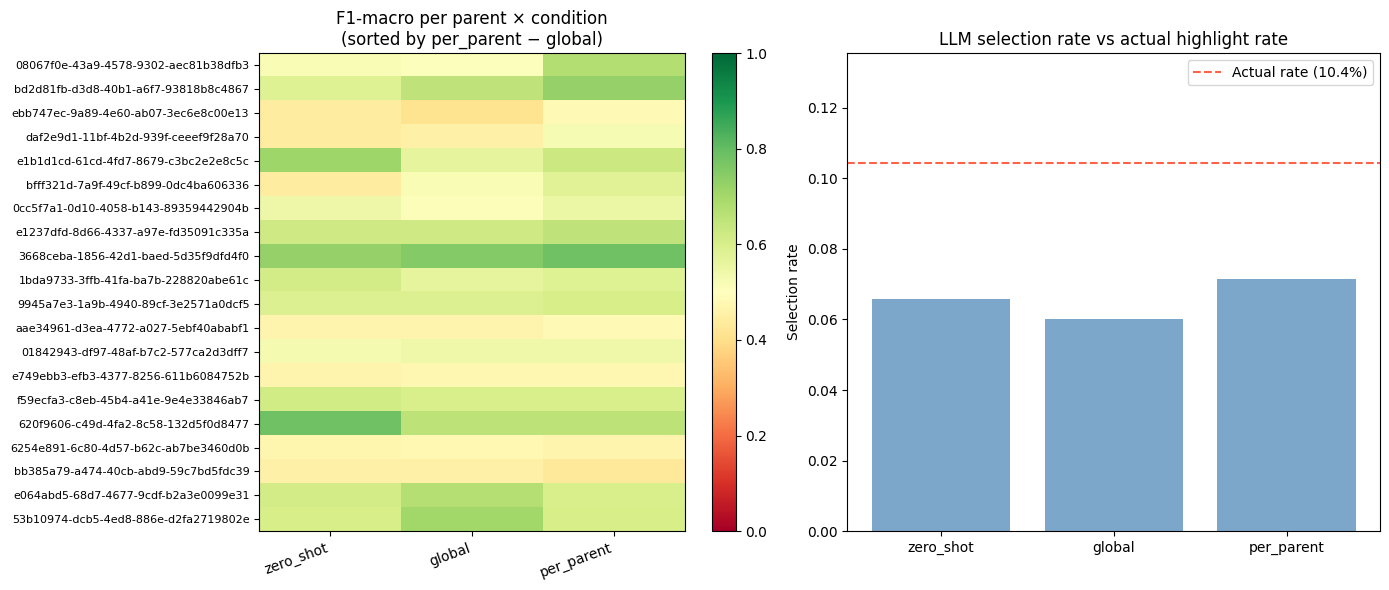


per_parent − global (positive = personalization helps):


,precision,recall,f1_macro,f1_weighted,accuracy,selection_rate
delta,0.043,0.06,0.029,0.006,0.001,0.011


In [67]:
# ── Per-parent F1-macro heatmap ────────────────────────────────────────────
parent_f1 = []
for pid, grp in results_df.groupby('parent_id'):
    for cond, cgrp in grp.groupby('condition'):
        parent_f1.append({
            'parent_id': pid,
            'condition': cond,
            'f1_macro':  f1_score(cgrp['y_true'], cgrp['y_pred'],
                                  average='macro', zero_division=0),
        })

parent_f1_df = pd.DataFrame(parent_f1)
heatmap_data = parent_f1_df.pivot(index='parent_id', columns='condition', values='f1_macro')

# Sort parents by (per_parent − global) improvement
if 'per_parent' in heatmap_data and 'global' in heatmap_data:
    heatmap_data['_delta'] = heatmap_data['per_parent'] - heatmap_data['global']
    heatmap_data = heatmap_data.sort_values('_delta', ascending=False)
    heatmap_data = heatmap_data.drop(columns='_delta')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
ax = axes[0]
im = ax.imshow(heatmap_data[CONDITION_ORDER].values, aspect='auto', cmap='RdYlGn',
               vmin=0, vmax=1)
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels(CONDITION_ORDER, rotation=20, ha='right')
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=8)
ax.set_title('F1-macro per parent × condition\n(sorted by per_parent − global)')
plt.colorbar(im, ax=ax)

# Selection rate comparison
ax2 = axes[1]
sel_rates = [metrics_df.loc[c, 'selection_rate'] if c in metrics_df.index else 0
             for c in CONDITION_ORDER]
ax2.bar(CONDITION_ORDER, sel_rates, color='steelblue', alpha=0.7)
ax2.axhline(actual_rate, color='tomato', linestyle='--', linewidth=1.5,
            label=f'Actual rate ({actual_rate:.1%})')
ax2.set_ylabel('Selection rate')
ax2.set_title('LLM selection rate vs actual highlight rate')
ax2.legend()
ax2.set_ylim(0, max(sel_rates + [actual_rate]) * 1.3)

plt.tight_layout()
plt.show()

# Numeric delta table
if 'per_parent' in metrics_df.index and 'global' in metrics_df.index:
    delta = metrics_df.loc['per_parent'] - metrics_df.loc['global']
    print('\nper_parent − global (positive = personalization helps):')
    display(delta.to_frame('delta').T.round(3))